# Score Distribution: TNFA Binders vs ZINC Training Data

In [21]:
import os
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, QED
import matplotlib.pyplot as plt
import gzip, sys, os, importlib

sys.path.insert(0, "/Users/kaitlynramesh/CBB_5801/jtvae-tnfa/")

import tnfa_oracle; importlib.reload(tnfa_oracle)
from tnfa_oracle import batch_score_components, NOVELTY_THRESHOLD

In [22]:
SEED = 42
N_ZINC = 500
BASE = "/Users/kaitlynramesh/CBB_5801/jtvae-tnfa/"

# --- JT-VAE predicted binders ---
cand_path = os.path.join(BASE, "results", "jtvae_tnfa", "candidates_20260421_153136.csv")
cand_df = pd.read_csv(cand_path)
cand_smiles = cand_df["smiles"].dropna().tolist()
print(f"JT-VAE candidates: {len(cand_smiles)}")

# --- Top-100 known binders (by affinity) ---
top100_path = os.path.join(BASE, "data", "tnfa_jtvae", "top100_binders.txt")
top100_smiles = pd.read_csv(top100_path, header=None)[0].dropna().tolist()
print(f"Top-100 known binders: {len(top100_smiles)}")

# --- ZINC baseline ---
zinc_path = "/Users/kaitlynramesh/CBB_5801/0416_MolOpt/mol_opt/data/zinc.csv.gz"
with gzip.open(zinc_path, "rt") as f:
    zinc_smiles = [line.strip() for line in f if line.strip() and not line.startswith("SMILES")]
rng = np.random.default_rng(SEED)
zinc_sample = rng.choice(zinc_smiles, size=N_ZINC, replace=False).tolist()
print(f"ZINC sample: {len(zinc_sample)}")

JT-VAE candidates: 248
Top-100 known binders: 100
ZINC sample: 500


In [23]:
print("Scoring JT-VAE candidates...")
cand_scored = batch_score_components(cand_smiles)
cand_scored["dataset"] = "JT-VAE predictions"

print("Scoring top-100 known binders...")
top100_scored = batch_score_components(top100_smiles)
top100_scored["dataset"] = "Top-100 known"

print("Scoring ZINC baseline...")
zinc_scored = batch_score_components(zinc_sample)
zinc_scored["dataset"] = "ZINC"

combined = pd.concat([zinc_scored, top100_scored, cand_scored], ignore_index=True)
print(combined.groupby("dataset")[["weighted_sim", "max_sim", "novelty", "qed", "final"]].describe().round(3))

Scoring JT-VAE candidates...


[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerat

Scoring top-100 known binders...
Scoring ZINC baseline...
                   weighted_sim                                            \
                          count   mean    std    min    25%    50%    75%   
dataset                                                                     
JT-VAE predictions        248.0  0.336  0.251  0.117  0.197  0.218  0.253   
Top-100 known             100.0  0.819  0.053  0.705  0.784  0.812  0.847   
ZINC                      500.0  0.030  0.072  0.000  0.000  0.000  0.000   

                          max_sim         ...    qed         final         \
                      max   count   mean  ...    75%    max  count   mean   
dataset                                   ...                               
JT-VAE predictions  0.923   248.0  0.384  ...  0.576  0.801  248.0  0.371   
Top-100 known       0.931   100.0  1.000  ...  0.388  0.593  100.0  0.673   
ZINC                0.315   500.0  0.034  ...  0.000  0.940  500.0  0.055   

                

[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerator
[16:26:12] DEPRECATION WARNING: please use MorganGenerat

In [24]:
cand_scored['smiles'] = cand_smiles

In [25]:
cand_scored

,weighted_sim,max_sim,novelty,is_novel,qed,final,dataset,smiles
0,0.834017,1.000000,0.000000,0,0.592980,0.761706,JT-VAE predictions,COc1ccc2c(c1F)C(=O)N(C[C@@]1(C#Cc3cccnc3)NC(=O...
1,0.922940,1.000000,0.000000,0,0.356623,0.753045,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
2,0.910262,1.000000,0.000000,0,0.336971,0.738275,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
3,0.905684,1.000000,0.000000,0,0.339425,0.735806,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
4,0.923196,1.000000,0.000000,0,0.291421,0.733663,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
...,...,...,...,...,...,...,...,...
243,0.182672,0.185930,0.814070,1,0.260639,0.206062,JT-VAE predictions,COC1(c2c(=O)n(CCOc3cc(C(=O)N4CCCC4=O)ccc3C)nc3...
244,0.179612,0.214953,0.785047,1,0.267584,0.206004,JT-VAE predictions,CCOC(=O)C[NH2+]c1cc(C2=NN3CN(CC(=O)O)C(=O)C(C#...
245,0.188078,0.196581,0.803419,1,0.231467,0.201095,JT-VAE predictions,COC(=O)c1c(C)c(-c2ccc(N)c(C(=O)N3CCC4(C3)NC(=O...
246,0.162529,0.164062,0.835938,1,0.279309,0.197563,JT-VAE predictions,COC(=O)C1OCCNC1CC(=O)N1C2(CC34CC[NH2+]CC13CC(F...


In [15]:
novel_candidates = cand_scored[cand_scored['is_novel'] == 1]
novel_smiles = cand_scored.loc[cand_scored['is_novel'] == 1, 'smiles']
top10 = (
    novel_candidates[["weighted_sim", "max_sim", "novelty", "qed", "final"]]
    .assign(smiles=novel_candidates['smiles'])
    .sort_values("final", ascending=False)
    .head(10)
    [["smiles", "final", "max_sim", "novelty", "qed"]]
    .rename(columns={"final": "oracle_score", "max_sim": "tanimoto_max", "novelty": "novelty (1-sim)"})
    .reset_index(drop=True)
)
top10.index += 1
top10.round(4)

,smiles,oracle_score,tanimoto_max,novelty (1-sim),qed
1,CCC1CCC(=O)N(C(=O)COC(=O)c2cccc(C)c2)C1,0.4065,0.3099,0.6901,0.8008
2,CCCN1CCN(C(=O)c2ccc(CNC(=O)c3c(C)[nH]c(=O)n(C)...,0.3892,0.3571,0.6429,0.6974
3,CCOc1ccc(OC)c(CN2N=C(c3cc(C(=O)N4CCN(CC)CC4)cc...,0.3869,0.3265,0.6735,0.5820
4,Cc1oc2ccccc2c(=O)c1C=Cc1cccc(C(=O)N2CCCC2)c1,0.3845,0.2738,0.7262,0.6914
5,COCC1=CNC(=O)C1=NC(=O)Cc1cccc(N2C(=O)c3ccc(OC)...,0.3829,0.2581,0.7419,0.6934
6,COCN(C(=O)Cc1ccc(C)cc1)C(=O)c1ccc(C)c(F)c1,0.3803,0.2090,0.7910,0.7912
7,CCn1nc(C)c(C=C(C#N)c2cccc(OC)c2)c1OC,0.3786,0.2469,0.7531,0.7945
8,COc1cccc(C2c3c(cc(F)c4c3CCCO4)C(=O)N2CCC[NH+]2...,0.3775,0.2232,0.7768,0.7454
9,Cc1ncc(CN2C(=O)c3ccc(C(=O)N4CCCC4)cc3C2=O)nc1O...,0.3760,0.3256,0.6744,0.5834
10,COc1cccc(C2=C(N3CCN(C(=O)Oc4cc5c(cc4F)OC(C)(C)...,0.3731,0.2358,0.7642,0.7152


In [26]:
top10.to_csv('top_10_novel_candidates.csv', index=False)

In [ ]:
# out_path = os.path.join(BASE, "results", "jtvae_tnfa", "candidates_scored.csv")
# (
#     cand_scored
#     .rename(columns={"final": "oracle_score", "max_sim": "tanimoto_max", "novelty": "novelty_score"})
#     [["smiles", "oracle_score", "tanimoto_max", "novelty_score", "qed", "weighted_sim"]]
#     .sort_values("oracle_score", ascending=False)
#     .reset_index(drop=True)
#     .to_csv(out_path, index=False)
# )
# print(f"Saved {len(cand_smiles)} candidates → {out_path}")

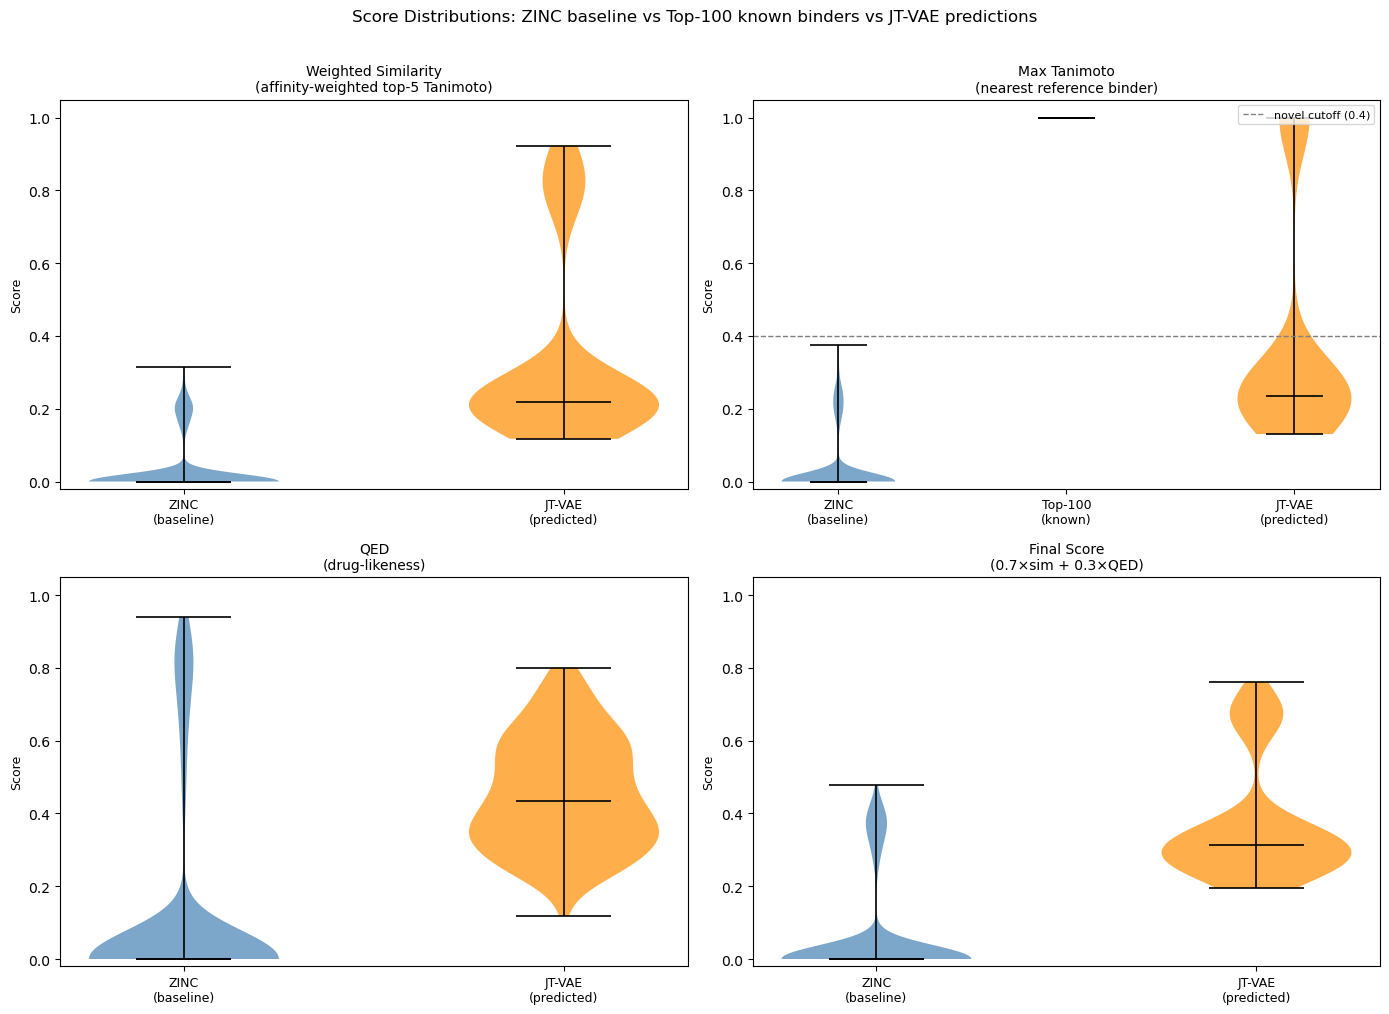

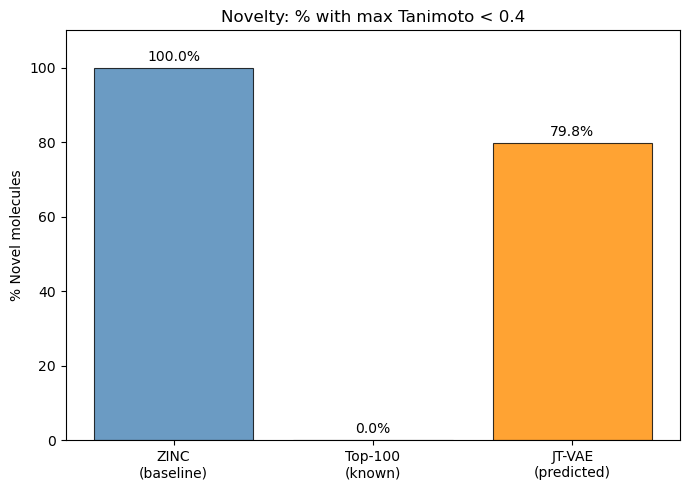

In [31]:
components = [
    ("weighted_sim", "Weighted Similarity\n(affinity-weighted top-5 Tanimoto)"),
    ("max_sim",      "Max Tanimoto\n(nearest reference binder)"),
    ("qed",          "QED\n(drug-likeness)"),
    ("final",        "Final Score\n(0.7×sim + 0.3×QED)"),
]

all_datasets = ["ZINC",            "Top-100 known",   "JT-VAE predictions"]
all_labels   = ["ZINC\n(baseline)", "Top-100\n(known)", "JT-VAE\n(predicted)"]
all_colors   = ["steelblue",        "tomato",            "darkorange"]

# Top-100 only shown for max_sim
show_top100 = {"max_sim"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (ax, (col, title)) in enumerate(zip(axes.flatten(), components)):
    if col in show_top100:
        ds_list, lbl_list, clr_list = all_datasets, all_labels, all_colors
    else:
        ds_list  = [d for d in all_datasets  if d != "Top-100 known"]
        lbl_list = [l for l, d in zip(all_labels,  all_datasets) if d != "Top-100 known"]
        clr_list = [c for c, d in zip(all_colors,  all_datasets) if d != "Top-100 known"]

    positions = list(range(1, len(ds_list) + 1))
    data = [combined.loc[combined["dataset"] == ds, col].values for ds in ds_list]
    parts = ax.violinplot(data, positions=positions, showmedians=True, showextrema=True)
    for pc, color in zip(parts["bodies"], clr_list):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    for key in ("cmedians", "cmins", "cmaxes", "cbars"):
        parts[key].set_color("black")
        parts[key].set_linewidth(1.2)
    ax.set_xticks(positions)
    ax.set_xticklabels(lbl_list, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-0.02, 1.05)
    ax.set_ylabel("Score", fontsize=9)
    if col == "max_sim":
        ax.axhline(NOVELTY_THRESHOLD, color="gray", linestyle="--", linewidth=1,
                   label=f"novel cutoff ({NOVELTY_THRESHOLD})")
        ax.legend(fontsize=8)

fig.suptitle("Score Distributions: ZINC baseline vs Top-100 known binders vs JT-VAE predictions",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# --- % novel per dataset ---
fig, ax = plt.subplots(figsize=(7, 5))
pct_novel = [combined.loc[combined["dataset"] == ds, "is_novel"].mean() * 100 for ds in all_datasets]
bars = ax.bar(all_labels, pct_novel, color=all_colors, alpha=0.8, edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, pct_novel):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("% Novel molecules")
ax.set_title(f"Novelty: % with max Tanimoto < {NOVELTY_THRESHOLD}")
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("novelty_pct.png", dpi=150, bbox_inches="tight")
plt.show()

## Score Components: Diverse Top 10 Candidates

In [ ]:
diverse_top10 = pd.read_csv(os.path.join(BASE, "diverse_top10_candidates.csv"))
diverse_components = batch_score_components(diverse_top10["smiles"].tolist())
diverse_components.insert(0, "rank", diverse_top10["rank"].values)
diverse_components.insert(1, "smiles", diverse_top10["smiles"].values)
diverse_components.round(4)